# [Bayesian Belief Networks (BBN) and Directed Acyclic Graphs (DAG)](https://towardsdatascience.com/bbn-bayesian-belief-networks-how-to-build-them-effectively-in-python-6b7f93435bba)
Bayesian Belief Network (BBN) is a Probabilistic Graphical Model (PGM) that represents a set of variables and their conditional dependencies via a Directed Acyclic Graph (DAG).


<img src="https://user-images.githubusercontent.com/24211929/212396040-3d0dcb4a-eb23-45c1-b1f0-8fb34590d504.png" width="200"/>
Using the above, we can state the relationship between variables (nodes):

- Independence: A and C are independent of each other. So are B and C. This is because knowing whether C has happened does not change our knowledge about A or B and vice versa.
- Dependence: B is dependent on A since A is the parent of B. This relationship can be written as a conditional probability: P(B|A). D is also dependent on other variables, and in this case, it depends on two of them — B and C. Again, this can be written as a conditional probability: P(D|B,C).
- Conditional Independence: D is considered conditionally independent of A. This is because as soon as we know whether event B has happened, A becomes irrelevant from the perspective of D. In other words, the following is true: `P(D|B,A) = P(D|B)`.

# Data and Python library setup
Using the following data and libraries:

- Australian weather data from Kaggle
- `PyBBN` for creating Bayesian Belief Networks
- `pandas` for data manipulation
- `networkx` and `matplotlib` for drawing graphs

In [73]:
import pandas as pd # for data manipulation 
import networkx as nx # for drawing graphs
from networkx.drawing.nx_agraph import graphviz_layout
import matplotlib.pyplot as plt # for drawing graphs
from netgraph import Graph, InteractiveGraph, EditableGraph
%matplotlib inline
# for creating Bayesian Belief Networks (BBN)
import pybbn
from pybbn.graph.dag import Bbn as bbn
from pybbn.graph.edge import Edge, EdgeType
from pybbn.graph.jointree import EvidenceBuilder
from pybbn.graph.node import BbnNode as bbnNode
from pybbn.graph.variable import Variable
from pybbn.pptc.inferencecontroller import InferenceController

import warnings
warnings.filterwarnings('ignore')

In [74]:
# Read in the weather data csv
df=pd.read_csv('weatherAUS.csv', encoding='utf-8')

# Drop records where target RainTomorrow=NaN
df=df[pd.isnull(df['RainTomorrow'])==False]

# For other columns with missing values, fill them in with column mean
df=df.fillna(df.mean())

# Create bands for variables that we want to use in the model
df['WindGustSpeedCat']=df['WindGustSpeed'].apply(lambda x: '0.<=40'   if x<=40 else
                                                            '1.40-50' if 40<x<=50 else '2.>50')
df['Humidity9amCat']=df['Humidity9am'].apply(lambda x: '1.>60' if x>60 else '0.<=60')
df['Humidity3pmCat']=df['Humidity3pm'].apply(lambda x: '1.>60' if x>60 else '0.<=60')

# Show a snaphsot of data
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,WindDir3pm,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,WindGustSpeedCat,Humidity9amCat,Humidity3pmCat
0,2008-12-01,Albury,13.4,22.9,0.6,5.469824,7.624853,W,44.0,W,WNW,20.0,24.0,71.0,22.0,1007.7,1007.1,8.000000,4.503167,16.9,21.8,No,No,1.40-50,1.>60,0.<=60
1,2008-12-02,Albury,7.4,25.1,0.0,5.469824,7.624853,WNW,44.0,NNW,WSW,4.0,22.0,44.0,25.0,1010.6,1007.8,4.437189,4.503167,17.2,24.3,No,No,1.40-50,0.<=60,0.<=60
2,2008-12-03,Albury,12.9,25.7,0.0,5.469824,7.624853,WSW,46.0,W,WSW,19.0,26.0,38.0,30.0,1007.6,1008.7,4.437189,2.000000,21.0,23.2,No,No,1.40-50,0.<=60,0.<=60
3,2008-12-04,Albury,9.2,28.0,0.0,5.469824,7.624853,NE,24.0,SE,E,11.0,9.0,45.0,16.0,1017.6,1012.8,4.437189,4.503167,18.1,26.5,No,No,0.<=40,0.<=60,0.<=60
4,2008-12-05,Albury,17.5,32.3,1.0,5.469824,7.624853,W,41.0,ENE,NW,7.0,20.0,82.0,33.0,1010.8,1006.0,7.000000,8.000000,17.8,29.7,No,No,1.40-50,1.>60,0.<=60


In [75]:
H9am = bbnNode(Variable(0, 'H9am', ['<=60', '>60']), [0.30658, 0.69342])
H3pm = bbnNode(Variable(1, 'H3pm', ['<=60', '>60']), [0.92827, 0.07173, 
                                                      0.55760, 0.44240])
W = bbnNode(Variable(2, 'W', ['<=40', '40-50', '>50']), [0.58660, 0.24040, 0.17300])
RT = bbnNode(Variable(3, 'RT', ['No', 'Yes']), [0.92314, 0.07686, 
                                                0.89072, 0.10928, 
                                                0.76008, 0.23992, 
                                                0.64250, 0.35750, 
                                                0.49168, 0.50832, 
                                                0.32182, 0.67818])

In [76]:
# Create Network
bbn = bbn() \
    .add_node(H9am) \
    .add_node(H3pm) \
    .add_node(W) \
    .add_node(RT) \
    .add_edge(Edge(H9am, H3pm, EdgeType.DIRECTED)) \
    .add_edge(Edge(H3pm, RT, EdgeType.DIRECTED)) \
    .add_edge(Edge(W, RT, EdgeType.DIRECTED))

# Convert the BBN to a join tree
join_tree = InferenceController.apply(bbn)

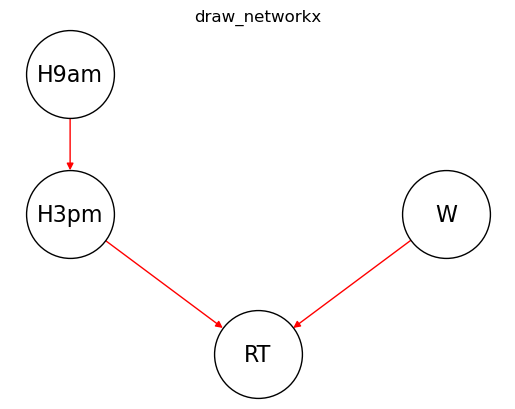

In [77]:
# Generate graph
n, d = bbn.to_nx_graph()

options = {
    "font_size": 16,
    "node_size": 4000,
    "node_color": "white",
    "edgecolors": "black",
    "edge_color": "red",
    "linewidths": 1,
    "width": 1,}
# nx.draw_networkx(n, with_labels=True, labels=d, **options)

plt.title('draw_networkx')
pos=graphviz_layout(n, prog='dot')
nx.draw(n, pos, with_labels=True, labels=d,**options)


# Update margins and print the graph
ax = plt.gca()
ax.margins(0.10)
plt.axis("off")
plt.show()

In [86]:
def print_probs(join_tree):
    for node in join_tree.get_bbn_nodes():
        print("Node:", node)
        potential = join_tree.get_bbn_potential(node)
        pdf = potential_to_df(potential)
        display(pdf)
#         print("Values:")
#         print(potential)
#         print('----------------')
        
# Use the above function to print marginal probabilities
print_probs(join_tree)

Node: 1|H3pm|<=60,>60


,val,p
0,<=60,0.67124
1,>60,0.32876


Node: 0|H9am|<=60,>60


,val,p
0,<=60,0.30658
1,>60,0.69342


Node: 2|W|<=40,40-50,>50


,val,p
0,<=40,0.5866
1,40-50,0.2404
2,>50,0.1730


Node: 3|RT|No,Yes


,val,p
0,No,0.776551
1,Yes,0.223449


In [83]:
def potential_to_df(p):
    data = []
    for pe in p.entries:
        try:
            v = pe.entries.values()[0]
        except:
            v = list(pe.entries.values())[0]
        p = pe.value
        t = (v, p)
        data.append(t)
    return pd.DataFrame(data, columns=['val', 'p'])

def potentials_to_dfs(join_tree):
    data = []
    for node in join_tree.get_bbn_nodes():
        name = node.variable.name
        df = potential_to_df(join_tree.get_bbn_potential(node))
        t = (name, df)
        data.append(t)
    return data

marginal_dfs = potentials_to_dfs(join_tree)
display(marginal_dfs)

[('H3pm',
      val        p
  0  <=60  0.67124
  1   >60  0.32876),
 ('H9am',
      val        p
  0  <=60  0.30658
  1   >60  0.69342),
 ('W',
       val       p
  0   <=40  0.5866
  1  40-50  0.2404
  2    >50  0.1730),
 ('RT',
     val         p
  0   No  0.776551
  1  Yes  0.223449)]

In [ ]:
# To add evidence of events that happened so probability distribution can be recalculated
def evidence(ev, nod, cat, val):
    ev = EvidenceBuilder() \
    .with_node(join_tree.get_bbn_node_by_name(nod)) \
    .with_evidence(cat, val) \
    .build()
    join_tree.set_observation(ev)
    
# Use above function to add evidence
evidence('ev1', 'H9am', '>60', 1.0)
